# Notebook 1: Latent-Threshold Models for Ordinal Data

**Time:** 60--90 minutes

**Purpose:** Build intuition for ordinal data, the latent-threshold (cutpoint) construction, and the cutpoint--probability duality. Implement an ordered logistic model in PyMC and see how covariates shift the ordinal distribution.

**Prerequisites:** Notebook 0 (PyMC basics). Familiarity with CDFs, logistic/normal distributions, Bayesian inference.

**DCM context:** Experts will rate indicators on a 7-point Likert scale. This notebook builds the modelling foundation for that observation layer.

In [26]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy.special import expit, logit
from scipy.stats import norm

rng = np.random.default_rng(42)

### Learning objectives

1. Explain why ordinal data need a specialised model (not integer regression, not free categorical).
2. Construct ordinal probabilities from cutpoints and a CDF, and invert the map.
3. Distinguish ordered logit from ordered probit.
4. Fit an intercept-only ordered logistic model in PyMC.
5. Explain how translating the latent density shifts ordinal probabilities (the mechanism behind regression).

## 1. Ordinal data

An **ordinal space** is a finite set whose elements have a strict ordering:

$$y_1 \prec y_2 \prec \cdots \prec y_K.$$

The classic example is a Likert scale: "Strongly disagree", "Disagree", ..., "Strongly agree". In the DCM, experts will rate indicator presence on a 7-point scale ($K = 7$).

The ordering is meaningful -- a rating of 5 is "more" than a rating of 3 -- but the **distances between categories are not**. There is no guarantee that the gap between categories 2 and 3 is the same as between 5 and 6.

### Why not integer regression?

Treating ordinal values as metric (e.g. a normal likelihood on $\{1, \ldots, 7\}$) assumes equal spacing, permits fractional predictions (what does 3.7 mean on a Likert scale?), and assigns density outside the support. This is generally inappropriate.

### Why not a free categorical model?

A `pm.Categorical` with a Dirichlet prior treats $\{1, \ldots, K\}$ as an **unordered set**. It cannot express the constraint that perturbing a latent state should shift mass to *adjacent* categories rather than arbitrary ones. It offers no structural compression -- just $K - 1$ free parameters on the simplex with no notion of neighbourhood.

We need a model that respects ordering without assuming metricality. The **latent-threshold construction** does exactly this.

## 2. The latent-threshold construction

### 2.1 Core idea

Posit a **latent continuous variable** $x \in \mathbb{R}$ with CDF $F$. Partition $\mathbb{R}$ into $K$ ordered intervals using $K - 1$ **cutpoints** (also called thresholds):

$$-\infty = c_0 < c_1 < c_2 < \cdots < c_{K-1} < c_K = \infty.$$

We observe ordinal category $y = k$ when $x$ falls in the interval $(c_{k-1},\; c_k]$. The probability of each category is then:

$$p_k = F(c_k) - F(c_{k-1}), \qquad k = 1, \ldots, K.$$

The cutpoints impose **ordinal structure**: because $F$ is monotone and continuous, small perturbations to a cutpoint trade probability mass only between adjacent categories.

### 2.2 Worked example: ordinal probabilities from cutpoints

**Micro-objective:** Given $K = 4$ categories and cutpoints $c = (-1,\; 0,\; 1.5)$ with a logistic latent density ($F = \text{expit}$), compute the ordinal probabilities $p_1, \ldots, p_4$ and verify they sum to 1.

In [27]:
# Forward map: cutpoints -> ordinal probabilities
cutpoints: np.ndarray = np.array([-1.0, 0.0, 1.5])
K: int = len(cutpoints) + 1  # 4 categories

# Augment with -inf and +inf
c_aug: np.ndarray = np.concatenate([[-np.inf], cutpoints, [np.inf]])

# Apply logistic CDF
F_vals: np.ndarray = expit(c_aug)  # expit(-inf)=0, expit(+inf)=1
print("F at augmented cutpoints:", np.round(F_vals, 4))

# Ordinal probabilities = consecutive differences of F
probs: np.ndarray = np.diff(F_vals)
print("Ordinal probabilities:   ", np.round(probs, 4))
print(f"Sum: {probs.sum():.6f}")

F at augmented cutpoints: [0.     0.2689 0.5    0.8176 1.    ]
Ordinal probabilities:    [0.2689 0.2311 0.3176 0.1824]
Sum: 1.000000


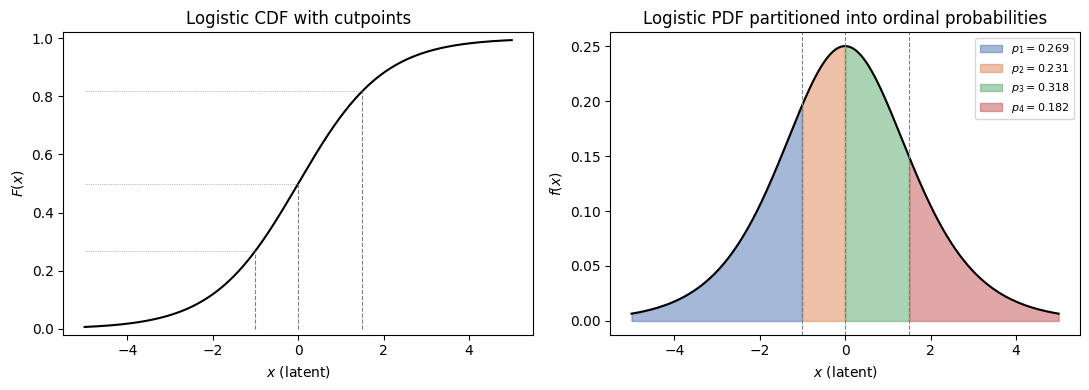

In [28]:
# Visualisation: logistic CDF partitioned by cutpoints
x_grid: np.ndarray = np.linspace(-5, 5, 500)
F_grid: np.ndarray = expit(x_grid)
f_grid: np.ndarray = F_grid * (1 - F_grid)  # logistic PDF

colours = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
labels = [f"$p_{k + 1} = {probs[k]:.3f}$" for k in range(K)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left panel: CDF with cutpoints
ax = axes[0]
ax.plot(x_grid, F_grid, "k-", lw=1.5)
for k in range(K - 1):
    ax.vlines(cutpoints[k], 0, expit(cutpoints[k]), ls="--", color="grey", lw=0.8)
    ax.hlines(expit(cutpoints[k]), -5, cutpoints[k], ls=":", color="grey", lw=0.5)
ax.set_xlabel("$x$ (latent)")
ax.set_ylabel("$F(x)$")
ax.set_title("Logistic CDF with cutpoints")
ax.set_ylim(-0.02, 1.02)

# Right panel: PDF with shaded regions
ax = axes[1]
ax.plot(x_grid, f_grid, "k-", lw=1.5)
boundaries = np.concatenate([[-5], cutpoints, [5]])
for k in range(K):
    mask = (x_grid >= boundaries[k]) & (x_grid <= boundaries[k + 1])
    ax.fill_between(
        x_grid[mask], f_grid[mask], alpha=0.5, color=colours[k], label=labels[k]
    )
for c in cutpoints:
    ax.axvline(c, ls="--", color="grey", lw=0.8)
ax.set_xlabel("$x$ (latent)")
ax.set_ylabel("$f(x)$")
ax.set_title("Logistic PDF partitioned into ordinal probabilities")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2.3 The inverse map: cutpoints from probabilities

Given ordinal probabilities $(p_1, \ldots, p_K)$ summing to 1, we can recover the cutpoints via cumulative sums and the **inverse CDF** (quantile function):

$$c_k = F^{-1}\!\left(\sum_{j=1}^{k} p_j\right), \qquad k = 1, \ldots, K-1.$$

This is a **bijection** for any fixed latent CDF $F$: cutpoints and ordinal probabilities are dual representations of the same object. You can always convert freely between them.

(This is closely related to the stick-breaking construction used to unconstrain simplices -- each cumulative probability $\sum_{j \le k} p_j$ is a "break point" on $[0, 1]$, and applying $F^{-1}$ maps it to the real line.)

In [29]:
# Inverse map: ordinal probabilities -> cutpoints
p: np.ndarray = np.array([0.2, 0.3, 0.35, 0.15])

# Cumulative probabilities (drop the last one, which is always 1.0)
cum_p: np.ndarray = np.cumsum(p)[:-1]
print("Cumulative probabilities:", np.round(cum_p, 4))

# Apply inverse logistic CDF (= logit)
c_recovered: np.ndarray = logit(cum_p)
print("Recovered cutpoints:     ", np.round(c_recovered, 4))

# Round-trip check: forward map on recovered cutpoints
c_aug_check: np.ndarray = np.concatenate([[-np.inf], c_recovered, [np.inf]])
p_check: np.ndarray = np.diff(expit(c_aug_check))
print("Round-trip probabilities:", np.round(p_check, 4))
print(f"Max abs error: {np.max(np.abs(p - p_check)):.1e}")

Cumulative probabilities: [0.2  0.5  0.85]
Recovered cutpoints:      [-1.3863  0.      1.7346]
Round-trip probabilities: [0.2  0.3  0.35 0.15]
Max abs error: 2.8e-17


### Exercise 1: Forward and inverse maps with the normal CDF

Repeat the forward and inverse maps using the **normal (probit) CDF** instead of the logistic.

- Forward: compute ordinal probabilities for $K = 4$ with cutpoints $c = (-0.5, \; 0.5, \; 1.2)$.
- Inverse: recover the cutpoints from the probabilities you just computed.
- Verify the round-trip.

---

**Stop and try.** Write your solution in the cell below before checking.

<details><summary>Hint</summary>

Replace `expit` with `norm.cdf` for the forward map. Replace `logit` with `norm.ppf` for the inverse. The logic is identical.

</details>

<details><summary>Solution</summary>

```python
c_probit = np.array([-0.5, 0.5, 1.2])
c_aug_probit = np.concatenate([[-np.inf], c_probit, [np.inf]])

# Forward
p_probit = np.diff(norm.cdf(c_aug_probit))
print("Probit ordinal probs:", np.round(p_probit, 4))

# Inverse
cum_p_probit = np.cumsum(p_probit)[:-1]
c_check = norm.ppf(cum_p_probit)
print("Recovered cutpoints: ", np.round(c_check, 4))
print(f"Max abs error: {np.max(np.abs(c_probit - c_check)):.1e}")
```

</details>

In [30]:
# Exercise 1: your solution here
from typing import Any, Never


from numpy import dtype, ndarray


interior_cut_points = np.array([-0.5, 0.5, 1.2])
cut_points = np.concatenate(([-np.inf], interior_cut_points, [np.inf]))

cdf_vals = norm.cdf(cut_points)
ordinal_probs: ndarray[tuple[Any, ...], dtype[Any]] | ndarray[tuple[()], dtype[Any]] = (
    np.diff(cdf_vals)
)

cum_sum = np.cumsum(ordinal_probs)[:-1]  # remove last value (is 1.0)
cut_points = norm.ppf(cum_sum)
cut_points
#

array([-0.5,  0.5,  1.2])

### 2.4 Ordered logit vs. ordered probit

Both are instances of the latent-threshold model; they differ only in the choice of $F$:

| Model | Latent CDF $F$ | Inverse $F^{-1}$ | Tails |
|---|---|---|---|
| Ordered logit | $\sigma(x) = 1/(1 + e^{-x})$ | $\text{logit}(p) = \log \frac{p}{1-p}$ | Heavier |
| Ordered probit | $\Phi(x)$ (standard normal) | $\Phi^{-1}(p)$ | Lighter |

In practice, results are often very similar. The DCM will ultimately use an **ordered probit** (normal latent variable), but we work with the logit variant here because its closed-form CDF/inverse is convenient for building intuition. The concepts transfer directly.

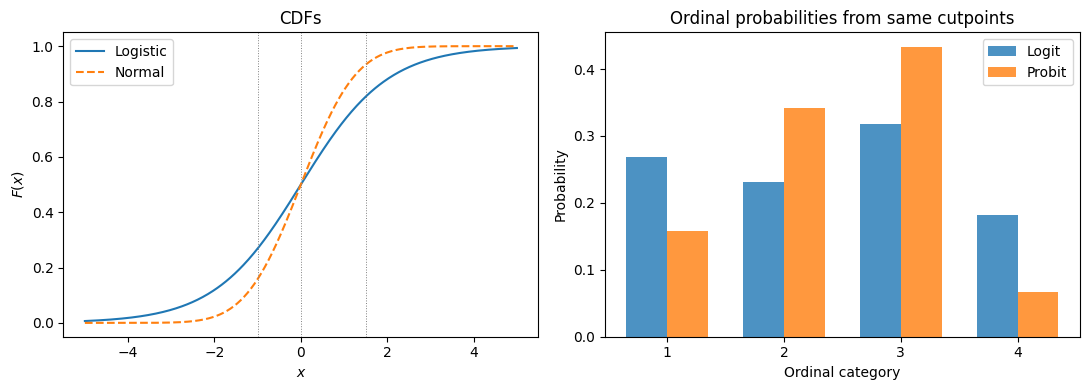

In [31]:
# Visual comparison: logistic vs normal CDF, and resulting ordinal probs
c_demo: np.ndarray = np.array([-1.0, 0.0, 1.5])
c_aug_demo: np.ndarray = np.concatenate([[-np.inf], c_demo, [np.inf]])

p_logit: np.ndarray = np.diff(expit(c_aug_demo))
p_probit: np.ndarray = np.diff(norm.cdf(c_aug_demo))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: CDFs
ax = axes[0]
ax.plot(x_grid, expit(x_grid), label="Logistic", lw=1.5)
ax.plot(x_grid, norm.cdf(x_grid), label="Normal", lw=1.5, ls="--")
for c in c_demo:
    ax.axvline(c, ls=":", color="grey", lw=0.7)
ax.set_xlabel("$x$")
ax.set_ylabel("$F(x)$")
ax.set_title("CDFs")
ax.legend()

# Right: bar chart of ordinal probs
ax = axes[1]
cats = np.arange(1, len(c_demo) + 2)
w: float = 0.35
ax.bar(cats - w / 2, p_logit, width=w, label="Logit", alpha=0.8)
ax.bar(cats + w / 2, p_probit, width=w, label="Probit", alpha=0.8)
ax.set_xlabel("Ordinal category")
ax.set_ylabel("Probability")
ax.set_title("Ordinal probabilities from same cutpoints")
ax.set_xticks(cats)
ax.legend()

plt.tight_layout()
plt.show()

### 2.5 Shifting the latent density: the key idea for regression

Here is the mechanism that makes the cutpoint construction useful for modelling **heterogeneous** ordinal data.

Introduce a **linear predictor** $\eta$ (Betancourt calls this the "affinity" parameter). Shifting the latent density by $\eta$ is equivalent to replacing $c_k$ with $c_k - \eta$ in the probability formula:

$$p_k(\eta) = F(c_k - \eta) - F(c_{k-1} - \eta).$$

- **Positive $\eta$**: the latent density shifts right, dragging probability mass toward **higher** ordinal values.
- **Negative $\eta$**: mass shifts toward **lower** ordinal values.
- The **shape** of the ordinal distribution is preserved; only its location changes.

In a regression, $\eta_i = \mathbf{x}_i^\top \boldsymbol{\beta}$, so covariates control the shift. For the DCM, the two "groups" are indicator-absent ($z = 0$) and indicator-present ($z = 1$), with the shift encoding how much the latent state changes expert ratings.

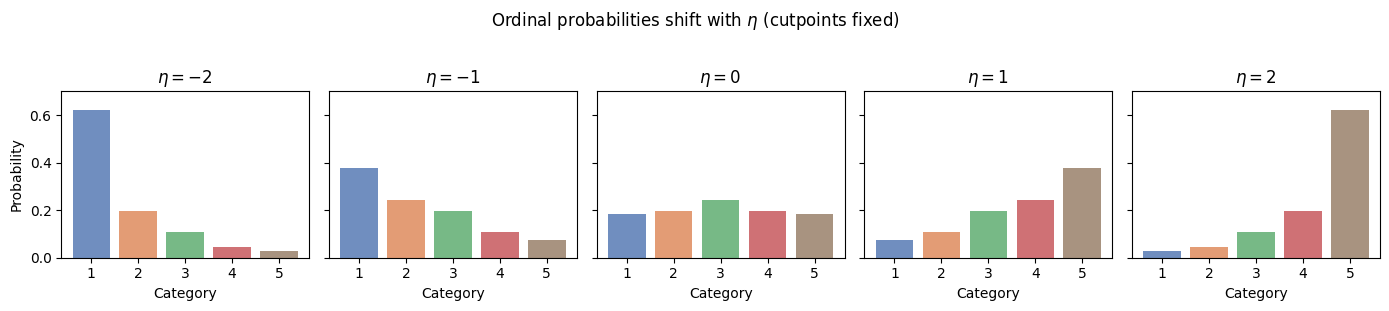

In [32]:
def ordinal_probs(cutpoints: np.ndarray, eta: float = 0.0) -> np.ndarray:
    """Compute ordinal probabilities from cutpoints and a linear predictor (logistic CDF)."""
    c_aug = np.concatenate([[-np.inf], cutpoints, [np.inf]])
    return np.diff(expit(c_aug - eta))


# Show how eta shifts the distribution
c_fixed: np.ndarray = np.array([-1.5, -0.5, 0.5, 1.5])
K_demo: int = len(c_fixed) + 1
etas: list[float] = [-2.0, -1.0, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(1, len(etas), figsize=(14, 3), sharey=True)
cats = np.arange(K_demo)

for ax, eta_val in zip(axes, etas):
    p_eta = ordinal_probs(c_fixed, eta_val)
    ax.bar(cats, p_eta, color=colours + ["#937860"], alpha=0.8)
    ax.set_title(f"$\\eta = {eta_val:.0f}$")
    ax.set_xticks(cats)
    ax.set_xticklabels([str(k + 1) for k in cats])
    ax.set_xlabel("Category")
    ax.set_ylim(0, 0.7)

axes[0].set_ylabel("Probability")
fig.suptitle("Ordinal probabilities shift with $\\eta$ (cutpoints fixed)", y=1.02)
plt.tight_layout()
plt.show()

### Exercise 2: Ordinal probabilities as a function of $\eta$ for $K = 7$

Write a version of the `ordinal_probs` function (or reuse the one above) to produce a plot like the one above, but for **$K = 7$ categories** (the DCM scale). Choose cutpoints that give a roughly symmetric baseline ($\eta = 0$) distribution. Plot panels for $\eta \in \{-2, -1, 0, 1, 2\}$.

---

**Stop and try.**

<details><summary>Hint</summary>

For a roughly symmetric baseline with $K = 7$, try evenly spaced cutpoints, e.g. `np.array([-1.5, -0.9, -0.3, 0.3, 0.9, 1.5])`. The `ordinal_probs` function already handles arbitrary $K$.

</details>

<details><summary>Solution</summary>

```python
c_7 = np.array([-1.5, -0.9, -0.3, 0.3, 0.9, 1.5])
K_7 = len(c_7) + 1
etas_7 = [-2.0, -1.0, 0.0, 1.0, 2.0]

fig, axes = plt.subplots(1, len(etas_7), figsize=(14, 3), sharey=True)
cats_7 = np.arange(K_7)

for ax, eta_val in zip(axes, etas_7):
    p_eta = ordinal_probs(c_7, eta_val)
    ax.bar(cats_7, p_eta, alpha=0.8)
    ax.set_title(f"$\\eta = {eta_val:.0f}$")
    ax.set_xticks(cats_7)
    ax.set_xticklabels([str(k + 1) for k in cats_7])
    ax.set_xlabel("Category")
    ax.set_ylim(0, 0.5)

axes[0].set_ylabel("Probability")
fig.suptitle("7-point Likert: ordinal probabilities shift with $\\eta$", y=1.02)
plt.tight_layout()
plt.show()
```

</details>

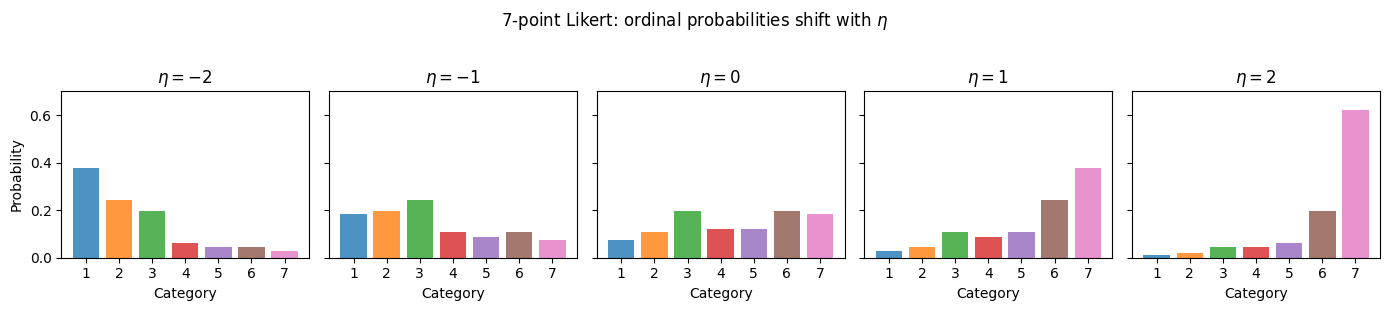

In [33]:
# Exercise 2: your solution here
c_fixed_7 = np.array([-2.5, -1.5, -0.5, 0.0, 0.5, 1.5])
K_7 = len(c_fixed_7) + 1
etas_7 = [-2.0, -1.0, 0.0, 1.0, 2.0]
colours_7 = [plt.cm.tab10(i) for i in range(K_7)]

fig, axes = plt.subplots(1, len(etas_7), figsize=(14, 3), sharey=True)
cats_7 = np.arange(K_7)

for ax, eta_val in zip(axes, etas_7):
    p_eta = ordinal_probs(c_fixed_7, eta_val)
    ax.bar(cats_7, p_eta, color=colours_7, alpha=0.8)
    ax.set_title(f"$\\eta = {eta_val:.0f}$")
    ax.set_xticks(cats_7)
    ax.set_xticklabels([str(k + 1) for k in cats_7])
    ax.set_xlabel("Category")
    ax.set_ylim(0, 0.7)

axes[0].set_ylabel("Probability")
fig.suptitle("7-point Likert: ordinal probabilities shift with $\\eta$", y=1.02)
plt.tight_layout()
plt.show()

## 3. Fitting an ordered logistic model in PyMC

Now we put the theory to work:
1. Generate synthetic ordinal data from known cutpoints.
2. Fit a `pm.OrderedLogistic` model and recover the cutpoints.
3. Compare against a free `pm.Categorical` model.

### 3.1 Generating synthetic data

We simulate $N = 200$ observations from $K = 5$ categories with true cutpoints $c = (-1.5, -0.5, 0.5, 1.5)$ and $\eta = 0$ (intercept-only -- no covariates yet).

**Convention:** PyMC's `OrderedLogistic` expects **0-indexed** observations ($0, 1, \ldots, K-1$), not $1, \ldots, K$.

True probabilities: [0.1824 0.1951 0.2449 0.1951 0.1824]


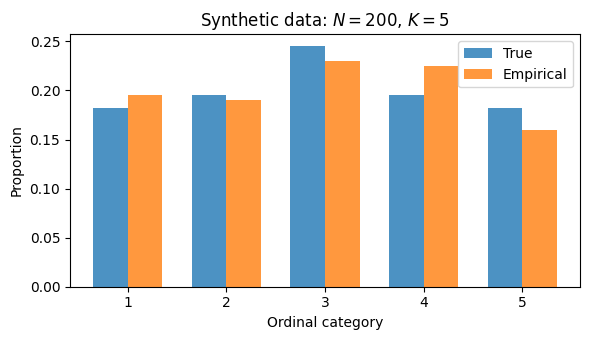

In [34]:
# True parameters
true_cutpoints: np.ndarray = np.array([-1.5, -0.5, 0.5, 1.5])
K_fit: int = len(true_cutpoints) + 1
N_fit: int = 200

# Compute true ordinal probabilities (eta = 0)
true_probs: np.ndarray = ordinal_probs(true_cutpoints, eta=0.0)
print("True probabilities:", np.round(true_probs, 4))

# Sample observed data (0-indexed)
y_obs: np.ndarray = rng.choice(K_fit, size=N_fit, p=true_probs)

# Empirical frequencies vs true
emp_freq: np.ndarray = np.bincount(y_obs, minlength=K_fit) / N_fit

fig, ax = plt.subplots(figsize=(6, 3.5))
w = 0.35
cats_fit = np.arange(K_fit)
ax.bar(cats_fit - w / 2, true_probs, width=w, label="True", alpha=0.8)
ax.bar(cats_fit + w / 2, emp_freq, width=w, label="Empirical", alpha=0.8)
ax.set_xticks(cats_fit)
ax.set_xticklabels([str(k + 1) for k in cats_fit])
ax.set_xlabel("Ordinal category")
ax.set_ylabel("Proportion")
ax.legend()
ax.set_title(f"Synthetic data: $N = {N_fit}$, $K = {K_fit}$")
plt.tight_layout()
plt.show()

### 3.2 Fitting the ordered logistic model

The PyMC model has two components:

- **Cutpoints prior:** We place a normal prior on an **ordered** vector. The `transform=pm.distributions.transforms.ordered` constraint ensures the sampler only explores configurations where $c_1 < c_2 < \cdots < c_{K-1}$.
- **Likelihood:** `pm.OrderedLogistic` computes the ordinal probabilities internally using the logistic CDF and evaluates the categorical log-likelihood. The `eta` argument is the linear predictor; for an intercept-only model we set it to a constant.

Setting `compute_p=True` stores the inferred ordinal probabilities in the trace (as `"y_p"`).

In [35]:
with pm.Model() as ordered_logit_model:
    # Cutpoints: normal prior with ordering constraint
    cp = pm.Normal(
        "cutpoints",
        mu=0.0,
        sigma=2.0,
        shape=K_fit - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1, 1, K_fit - 1),  # sensible starting values
    )
    # Likelihood (eta=0 for intercept-only)
    y_lik = pm.OrderedLogistic(
        "y", eta=0.0, cutpoints=cp, observed=y_obs, compute_p=True
    )

with ordered_logit_model:
    idata_ol = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


In [36]:
# Summary: do the posterior cutpoints concentrate near the true values?
az.summary(idata_ol, var_names=["cutpoints"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[0],-1.432,0.174,-1.755,-1.104,0.003,0.003,2954.0,2581.0,1.0
cutpoints[1],-0.474,0.145,-0.728,-0.195,0.002,0.002,4404.0,3499.0,1.0
cutpoints[2],0.472,0.144,0.206,0.749,0.002,0.002,4786.0,3194.0,1.0
cutpoints[3],1.675,0.190,1.320,2.024,0.003,0.002,4853.0,3717.0,1.0


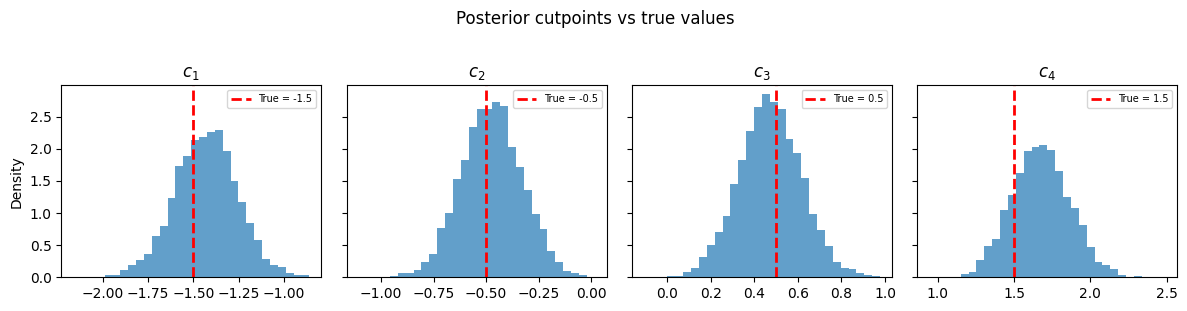

In [37]:
# Posterior cutpoints vs true values
fig, axes = plt.subplots(1, K_fit - 1, figsize=(12, 3), sharey=True)
for k in range(K_fit - 1):
    ax = axes[k]
    draws = idata_ol.posterior["cutpoints"].sel(cutpoints_dim_0=k).values.flatten()
    ax.hist(draws, bins=30, density=True, alpha=0.7)
    ax.axvline(
        true_cutpoints[k],
        color="red",
        lw=2,
        ls="--",
        label=f"True = {true_cutpoints[k]}",
    )
    ax.set_title(f"$c_{k + 1}$")
    ax.legend(fontsize=7)
axes[0].set_ylabel("Density")
plt.suptitle("Posterior cutpoints vs true values", y=1.02)
plt.tight_layout()
plt.show()

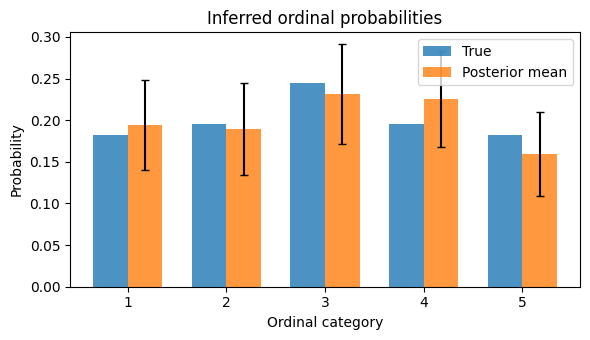

In [ ]:
# Posterior ordinal probabilities vs true (using compute_p=True output)
p_posterior: np.ndarray = (
    idata_ol.posterior["y_probs"].mean(dim=("chain", "draw")).values
)
p_posterior_sd: np.ndarray = (
    idata_ol.posterior["y_probs"].std(dim=("chain", "draw")).values
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(cats_fit - w / 2, true_probs, width=w, label="True", alpha=0.8)
ax.bar(
    cats_fit + w / 2,
    p_posterior,
    width=w,
    label="Posterior mean",
    alpha=0.8,
    yerr=2 * p_posterior_sd,
    capsize=3,
)
ax.set_xticks(cats_fit)
ax.set_xticklabels([str(k + 1) for k in cats_fit])
ax.set_xlabel("Ordinal category")
ax.set_ylabel("Probability")
ax.legend()
ax.set_title("Inferred ordinal probabilities")
plt.tight_layout()
plt.show()

### 3.3 Comparison: free categorical model

For contrast, fit a `pm.Categorical` model with a flat Dirichlet prior on the same data. This model ignores ordering entirely -- it treats the five categories as exchangeable labels.

In [40]:
with pm.Model() as categorical_model:
    p_cat = pm.Dirichlet("p", a=np.ones(K_fit))
    y_cat = pm.Categorical("y", p=p_cat, observed=y_obs)

with categorical_model:
    idata_cat = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

az.summary(idata_cat, var_names=["p"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p[0],0.195,0.027,0.146,0.248,0.001,0.0,2829.0,2624.0,1.0
p[1],0.190,0.027,0.138,0.238,0.000,0.0,3537.0,2723.0,1.0
p[2],0.230,0.029,0.178,0.287,0.001,0.0,3389.0,2808.0,1.0
p[3],0.224,0.028,0.172,0.279,0.000,0.0,3673.0,3188.0,1.0
p[4],0.161,0.026,0.114,0.210,0.000,0.0,5411.0,3007.0,1.0


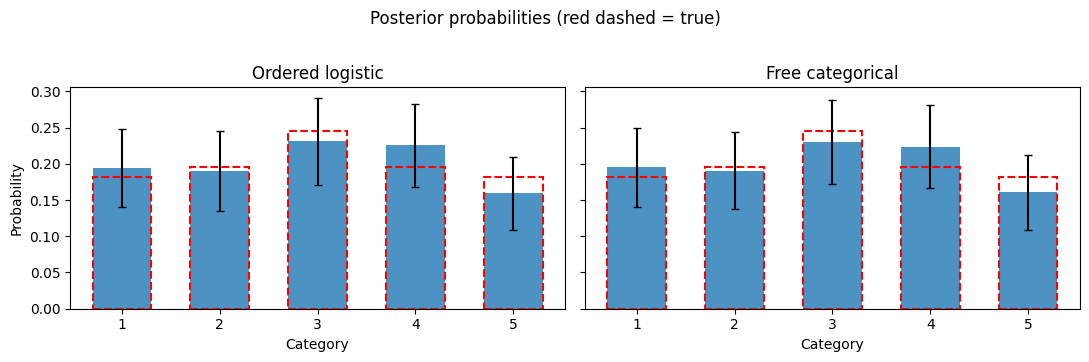

In [41]:
# Side-by-side: ordered logistic vs categorical posterior probabilities
p_cat_post: np.ndarray = idata_cat.posterior["p"].mean(dim=("chain", "draw")).values
p_cat_sd: np.ndarray = idata_cat.posterior["p"].std(dim=("chain", "draw")).values

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

ax = axes[0]
ax.bar(cats_fit, p_posterior, width=0.6, alpha=0.8, yerr=2 * p_posterior_sd, capsize=3)
ax.bar(cats_fit, true_probs, width=0.6, fill=False, edgecolor="red", ls="--", lw=1.5)
ax.set_title("Ordered logistic")
ax.set_xticks(cats_fit)
ax.set_xticklabels([str(k + 1) for k in cats_fit])
ax.set_xlabel("Category")
ax.set_ylabel("Probability")

ax = axes[1]
ax.bar(cats_fit, p_cat_post, width=0.6, alpha=0.8, yerr=2 * p_cat_sd, capsize=3)
ax.bar(cats_fit, true_probs, width=0.6, fill=False, edgecolor="red", ls="--", lw=1.5)
ax.set_title("Free categorical")
ax.set_xticks(cats_fit)
ax.set_xticklabels([str(k + 1) for k in cats_fit])
ax.set_xlabel("Category")

plt.suptitle("Posterior probabilities (red dashed = true)", y=1.02)
plt.tight_layout()
plt.show()

**What to take from this comparison:**

Both models recover similar marginal probabilities from this single dataset. The ordered model is not "better" at estimating marginals -- it has the same amount of information.

The advantage of the ordered model emerges when we **add covariates**. The cutpoint construction constrains how predictors shift the distribution: mass moves monotonically across adjacent categories via $\eta$. A free categorical model would allow arbitrary reshuffling of all $K$ probabilities per covariate level, requiring more parameters and losing the ordinal structure.

This is exactly why ordinal models matter for the DCM: a latent indicator state ($z = 0$ or $z = 1$) should **systematically shift** expert ratings, not arbitrarily rearrange them.

## 4. From intercept-only to regression: the role of $\eta$

We now extend to the setting that matters for the DCM: different groups produce systematically different ordinal responses because their latent states differ.

### 4.1 Two-group synthetic data

Simulate data from two groups sharing the same cutpoints but with different linear predictors:
- **Group A** ($\eta_A = 0$): baseline.
- **Group B** ($\eta_B = 1.5$): latent distribution shifted right, so ratings tend higher.

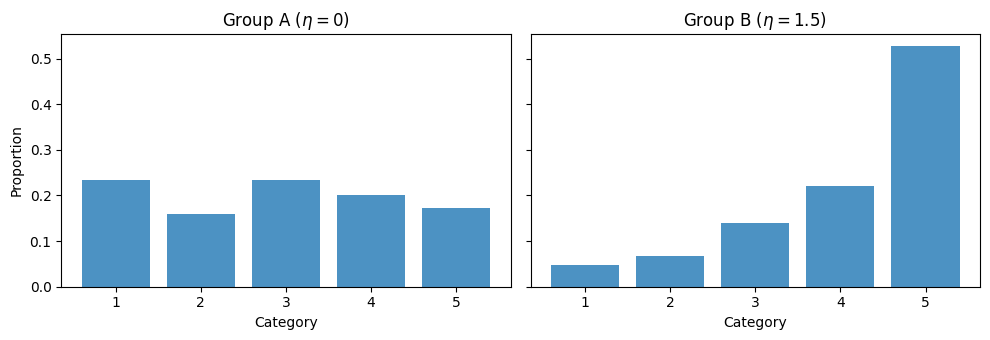

In [42]:
# Two-group data generation
true_beta: float = 1.5  # shift for group B
n_per_group: int = 150

# Group indicator: 0 = A, 1 = B
group: np.ndarray = np.repeat([0, 1], n_per_group)
eta_true: np.ndarray = true_beta * group  # 0 for A, 1.5 for B

# Sample ordinal responses per observation
y_two: np.ndarray = np.empty(len(group), dtype=int)
for i, eta_i in enumerate(eta_true):
    p_i = ordinal_probs(true_cutpoints, eta_i)
    y_two[i] = rng.choice(K_fit, p=p_i)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
for g, label in enumerate(
    ["Group A ($\\eta = 0$)", f"Group B ($\\eta = {true_beta}$)"]
):
    ax = axes[g]
    y_g = y_two[group == g]
    freq = np.bincount(y_g, minlength=K_fit) / len(y_g)
    ax.bar(cats_fit, freq, alpha=0.8)
    ax.set_xticks(cats_fit)
    ax.set_xticklabels([str(k + 1) for k in cats_fit])
    ax.set_xlabel("Category")
    ax.set_title(label)
axes[0].set_ylabel("Proportion")
plt.tight_layout()
plt.show()

### 4.2 Fitting the two-group model

The model estimates a single regression coefficient $\beta$ (the group shift) alongside the shared cutpoints. The linear predictor is $\eta_i = \beta \cdot \text{group}_i$.

In [43]:
with pm.Model() as two_group_model:
    # Shared cutpoints
    cp = pm.Normal(
        "cutpoints",
        mu=0.0,
        sigma=2.0,
        shape=K_fit - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1, 1, K_fit - 1),
    )
    # Regression coefficient
    beta = pm.Normal("beta", mu=0.0, sigma=3.0)
    # Linear predictor
    eta = beta * group
    # Likelihood
    y_lik = pm.OrderedLogistic(
        "y", eta=eta, cutpoints=cp, observed=y_two, compute_p=False
    )

with two_group_model:
    idata_two = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

az.summary(idata_two, var_names=["beta", "cutpoints"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, beta]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 568 draw iterations (4_000 + 2_272 draws total) took 363 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta,1.643,0.231,1.204,2.064,0.005,0.005,2322.0,1668.0,1.0
cutpoints[0],-1.246,0.186,-1.606,-0.908,0.004,0.004,2034.0,1686.0,1.0
cutpoints[1],-0.430,0.165,-0.747,-0.145,0.003,0.003,2421.0,1893.0,1.0
cutpoints[2],0.536,0.163,0.237,0.845,0.003,0.003,2501.0,2051.0,1.0
cutpoints[3],1.547,0.186,1.207,1.909,0.004,0.003,2226.0,1997.0,1.0


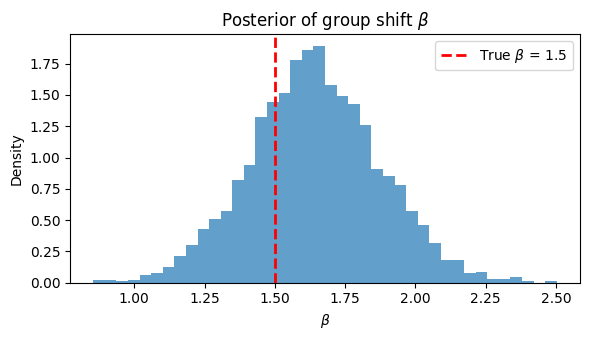

Posterior mean beta: 1.643
Posterior sd beta:   0.231


In [44]:
# Posterior of beta vs true value
fig, ax = plt.subplots(figsize=(6, 3.5))
beta_draws: np.ndarray = idata_two.posterior["beta"].values.flatten()
ax.hist(beta_draws, bins=40, density=True, alpha=0.7)
ax.axvline(true_beta, color="red", lw=2, ls="--", label=f"True $\\beta$ = {true_beta}")
ax.set_xlabel("$\\beta$")
ax.set_ylabel("Density")
ax.set_title("Posterior of group shift $\\beta$")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Posterior mean beta: {beta_draws.mean():.3f}")
print(f"Posterior sd beta:   {beta_draws.std():.3f}")

### Exercise 3: Three-group ordinal regression

Extend the two-group model to **three groups** with true shifts $\eta \in \{-1, \; 0, \; 1\}$. Use the same cutpoints as before.

1. Generate synthetic data with $n = 100$ observations per group.
2. Fit a PyMC model with two regression coefficients (use dummy coding: group 0 is the baseline with $\eta = 0$, and groups 1 and 2 have free coefficients $\beta_1, \beta_2$).
3. Check that the posteriors of $\beta_1, \beta_2$ recover the true shifts relative to baseline.

---

**Stop and try.**

<details><summary>Hint</summary>

One way to set up the dummy coding:

```python
# group_id: 0, 1, 2  (0 = baseline with eta = 0)
# True shifts relative to baseline: group 1 has eta = -1, group 2 has eta = +1
# So true beta = [-1.0, 1.0]
X = np.zeros((N_total, 2))
X[group_id == 1, 0] = 1.0  # dummy for group 1
X[group_id == 2, 1] = 1.0  # dummy for group 2
```

Then `eta = pm.math.dot(X, beta)` where `beta = pm.Normal("beta", mu=0, sigma=3, shape=2)`.

</details>

<details><summary>Solution</summary>

```python
n_three: int = 100
true_shifts = np.array([-1.0, 0.0, 1.0])  # group 0, 1, 2
group_id = np.repeat([0, 1, 2], n_three)

# Dummy coding: group 1 is baseline (eta = 0)
# Groups 0 and 2 get coefficients
X_three = np.zeros((len(group_id), 2))
X_three[group_id == 0, 0] = 1.0
X_three[group_id == 2, 1] = 1.0
true_betas = np.array([-1.0, 1.0])  # shifts relative to group 1

y_three = np.empty(len(group_id), dtype=int)
for i in range(len(group_id)):
    eta_i = true_shifts[group_id[i]]
    p_i = ordinal_probs(true_cutpoints, eta_i)
    y_three[i] = rng.choice(K_fit, p=p_i)

with pm.Model() as three_group:
    cp = pm.Normal("cutpoints", mu=0.0, sigma=2.0, shape=K_fit - 1,
                   transform=pm.distributions.transforms.ordered,
                   initval=np.linspace(-1, 1, K_fit - 1))
    beta = pm.Normal("beta", mu=0.0, sigma=3.0, shape=2)
    eta = pm.math.dot(X_three, beta)
    y_lik = pm.OrderedLogistic("y", eta=eta, cutpoints=cp, observed=y_three)

with three_group:
    idata_three = pm.sample(draws=1000, tune=1000, chains=4, random_seed=42)

print(az.summary(idata_three, var_names=["beta", "cutpoints"]))
print(f"\nTrue betas (relative to baseline group 1): {true_betas}")
```

</details>

In [51]:
# Exercise 3: your solution here
true_betas: float = np.array([0.0, 0.6, 2.2])  # shift for group B and C
n_per_group: int = 50

# Group indicator: 0 = A, 1 = B
group: np.ndarray = np.repeat([0, 1, 2], n_per_group)
eta_true: np.ndarray = np.repeat(true_betas, n_per_group)

X = np.zeros((len(group), 2))
X[group == 1, 0] = 1.0
X[group == 2, 1] = 1.0

# Sample ordinal responses per observation
y_three: np.ndarray = np.empty(len(group), dtype=int)
for i, eta_i in enumerate(eta_true):
    p_i = ordinal_probs(true_cutpoints, eta_i)
    y_three[i] = rng.choice(K_fit, p=p_i)


with pm.Model() as three_group_model:
    # Shared cutpoints
    cp = pm.Normal(
        "cutpoints",
        mu=0.0,
        sigma=2.0,
        shape=K_fit - 1,
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-1, 1, K_fit - 1),
    )
    # Regression coefficient
    beta = pm.Normal("beta", mu=0.0, sigma=3.0, shape=2)
    # Linear predictor
    eta = pm.math.dot(X, beta)
    # Likelihood
    y_lik = pm.OrderedLogistic(
        "y", eta=eta, cutpoints=cp, observed=y_three, compute_p=False
    )

with three_group_model:
    idata_three = pm.sample(draws=500, tune=500, chains=4, random_seed=42)

az.summary(idata_three, var_names=["beta", "cutpoints"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, beta]


/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/ryankelly/ryan-code/research/dcm-code/.venv/lib/python3.12/site-packages/pytensor/tensor/elemwise.py:1415: RuntimeWarning: invalid value encountered in reduce
  out = self.ufunc.reduce(input, axis=axis, dtype=acc_dtype)


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 125 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],0.884,0.355,0.227,1.526,0.009,0.007,1434.0,1468.0,1.0
beta[1],2.124,0.410,1.350,2.871,0.011,0.008,1506.0,1518.0,1.0
cutpoints[0],-1.377,0.298,-1.962,-0.843,0.008,0.007,1348.0,1123.0,1.0
cutpoints[1],-0.512,0.261,-0.983,-0.013,0.006,0.006,1751.0,1444.0,1.0
cutpoints[2],0.667,0.263,0.132,1.140,0.007,0.005,1596.0,1397.0,1.0
cutpoints[3],1.535,0.291,0.964,2.069,0.008,0.006,1376.0,1555.0,1.0


## 5. Connection to the DCM

The two-group model in Section 4 is the skeleton of the DCM observation layer:

| Two-group model | DCM observation layer |
|---|---|
| Group indicator (0 or 1) | Latent indicator state $z_{sj} \in \{0, 1\}$ |
| Group shift $\beta$ | Signal effect $a$ (how much indicator presence shifts ratings) |
| Shared cutpoints | Shared cutpoints $\kappa_1 < \cdots < \kappa_6$ (for $K = 7$) |
| Single observation per unit | Multiple experts per indicator: $r_{esj} \in \{1, \ldots, 7\}$ |

The current DCM approach averages expert probability judgements and then draws a single Bernoulli. The ordinal model instead treats **each expert's Likert rating** as an observation from a latent-threshold model, conditioning on whether the indicator is truly present.

**What comes next (Notebook 2):**
- **Identifiability:** the cutpoints and $\eta$ are only identified up to a common translation -- we need to anchor the model.
- **Shared vs. per-expert cutpoints:** what happens when experts use the rating scale differently.
- **SDT language:** how this latent-threshold model relates to signal detection theory (the "signal" is indicator presence; the "noise" is absence).
- **The marginal leaf likelihood:** how $P(r_{\cdot sj} \mid q_{sj}, \theta)$ integrates over the latent indicator state $z_{sj}$ and plugs into the DCM tree.

## Summary

**Key equation:**

$$p_k(\eta) = F(c_k - \eta) - F(c_{k-1} - \eta)$$

where $F$ is the logistic CDF (ordered logit) or normal CDF (ordered probit), $c_1 < \cdots < c_{K-1}$ are interior cutpoints, and $\eta$ is the linear predictor.

**What we covered:**

1. Ordinal data have ordering but no metric -- integer regression and free categorical models are both inappropriate.
2. The latent-threshold construction: cutpoints partition a latent continuous space into ordinal categories. Probabilities are CDF differences.
3. Cutpoints and ordinal probabilities are dual (bijection for fixed $F$).
4. Ordered logit and ordered probit differ only in $F$; results are typically similar.
5. Shifting $\eta$ monotonically shifts the ordinal distribution -- this is how covariates enter.

**PyMC patterns introduced:**
- `pm.OrderedLogistic(eta=..., cutpoints=..., observed=..., compute_p=True)`
- Ordered transform: `transform=pm.distributions.transforms.ordered`
- `initval=...` for sensible starting values on constrained parameters.

### Math exercise (pen and paper)

**Exercise 4:** Show that translating the latent density by $\delta$ (i.e. replacing $F(x)$ with $F(x + \delta)$) produces the same ordinal probabilities as shifting all cutpoints by $-\delta$ while keeping $F$ fixed.

That is, show:

$$F(c_k + \delta) - F(c_{k-1} + \delta) = F((c_k + \delta) - 0) - F((c_{k-1} + \delta) - 0)$$

where the left-hand side uses the translated density with original cutpoints, and the right-hand side uses the original density with shifted cutpoints $c'_k = c_k + \delta$.

*This is the fundamental reason why cutpoints and the linear predictor are non-identifiable without anchoring -- a fact we will study carefully in Notebook 2.*

---

**Stop and try.** This is a one-line argument.

<details><summary>Solution</summary>

Write $F_\delta(x) = F(x + \delta)$ for the CDF of the translated density. Then:

$$F_\delta(c_k) - F_\delta(c_{k-1}) = F(c_k + \delta) - F(c_{k-1} + \delta).$$

Now define shifted cutpoints $c'_k = c_k + \delta$. With the original CDF $F$ (no translation):

$$F(c'_k) - F(c'_{k-1}) = F(c_k + \delta) - F(c_{k-1} + \delta).$$

These are identical. So a translation of the latent density by $+\delta$ is indistinguishable from a shift of all cutpoints by $+\delta$ (equivalently, setting $\eta = -\delta$ in the regression formulation). Without fixing one, the other is unidentified.

</details>

## Anki

In [ ]:
# Q: Ordinal probability formula. Given cutpoints c_k and linear predictor eta,
#    what is P(y = k)?
# p_k(eta) = F(c_k - eta) - F(c_{k-1} - eta)
# where F is the latent CDF (logistic for ordered logit, normal for ordered probit)
# and c_0 = -inf, c_K = +inf

In [ ]:
# Q: Cutpoint-probability duality. Given ordinal probs (p_1, ..., p_K),
#    how do you recover cutpoints?
# c_k = F_inv( sum_{j=1}^{k} p_j )  for k = 1, ..., K-1
# i.e. apply the inverse CDF (logit or Phi_inv) to cumulative probabilities

In [ ]:
# Q: Why is there a location non-identifiability in ordinal models?
# Shifting all cutpoints by +delta and eta by +delta leaves all p_k unchanged:
#   F(c_k + delta - (eta + delta)) = F(c_k - eta)
# The likelihood has a ridge along this direction. Fix by anchoring one
# (e.g. drop the intercept, or fix one cutpoint to 0).

In [ ]:
# Q: Why not model ordinal data (e.g. Likert 1-7) as metric (integer regression)?
# Three problems:
# 1. Assumes equal spacing between categories (no reason to believe 2->3 = 5->6)
# 2. Permits fractional predictions (what does 3.7 mean on a Likert scale?)
# 3. Assigns density outside the support (e.g. below 1 or above 7)

In [ ]:
# Q: Why not use a free categorical (Dirichlet-Categorical) for ordinal data?
# It treats categories as exchangeable (unordered) -- no adjacency constraint.
# A covariate can arbitrarily reshuffle all K probs, rather than monotonically
# shifting mass across adjacent categories via eta. More parameters, less structure.

In [ ]:
# Q: Ordered logit vs ordered probit -- what is the difference?
# Same latent-threshold construction, different CDF F:
#   Logit:  F = sigmoid (logistic CDF), F_inv = logit.  Heavier tails.
#   Probit: F = Phi (standard normal CDF), F_inv = Phi_inv.  Lighter tails.
# Results are typically very similar in practice.

In [ ]:
# Q: How does the linear predictor eta shift ordinal probabilities?
# p_k(eta) = F(c_k - eta) - F(c_{k-1} - eta)
# Positive eta: latent density shifts right -> mass moves to higher categories
# Negative eta: shifts left -> mass moves to lower categories
# Shape preserved, only location changes. This is how covariates enter.